In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 04 — COMPARISON METHODS
# OLS Regression | Moran's I | K-means Clustering | TopoTests
# The Gluten-Free Gap: Spatial Inequalities in NHS Prescribing and
# Retail Accessibility Across England
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from scipy import stats
import statsmodels.api as sm
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'normal',
})

BLUE   = '#2a78d6'
GREEN  = '#1baf7a'
PURPLE = '#4a3aa7'
RED    = '#e34948'
AMBER  = '#eda100'
GREY   = '#73726c'

FIG_PATH = r'C:\Users\namra\gluten-free-spatial-inequality\outputs\figures'
TAB_PATH = r'C:\Users\namra\gluten-free-spatial-inequality\outputs\tables'

df = pd.read_csv(r'C:\Users\namra\gluten-free-spatial-inequality\data\processed\analytical_dataset_final.csv')

# Rebuild Ball Mapper partition at ε=1.5 for ARI comparisons
def ball_mapper(X, epsilon):
    n    = X.shape[0]
    dist = euclidean_distances(X)
    covered = np.zeros(n, dtype=bool)
    nodes   = {}
    nid     = 0
    for i in range(n):
        if not covered[i]:
            members = np.where(dist[i] <= epsilon)[0].tolist()
            nodes[nid] = members
            for j in members:
                covered[j] = True
            nid += 1
    edges = []
    ids   = list(nodes.keys())
    for a in range(len(ids)):
        for b in range(a + 1, len(ids)):
            if set(nodes[ids[a]]) & set(nodes[ids[b]]):
                edges.append((ids[a], ids[b]))
    return nodes, edges

def primary_node_partition(nodes, n_points):
    labels = np.full(n_points, -1)
    for nid, members in nodes.items():
        for m in members:
            if labels[m] == -1:
                labels[m] = nid
    return labels

variables = ['prescribing_rate_recent',
             'retail_accessibility_score',
             'imd_score_weighted']
X_raw    = df[variables].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

nodes_bm, _  = ball_mapper(X_scaled, 1.5)
bm_labels    = primary_node_partition(nodes_bm, len(df))
N_NODES_BM   = len(nodes_bm)  # 12

print(f"Dataset loaded: {df.shape}")
print(f"Ball Mapper partition rebuilt at ε=1.5: {N_NODES_BM} nodes")
print(f"K-means will use k={N_NODES_BM} to match Ball Mapper")

Dataset loaded: (106, 37)
Ball Mapper partition rebuilt at ε=1.5: 12 nodes
K-means will use k=12 to match Ball Mapper


OLS REGRESSION: prescribing ~ retail + IMD
                               OLS Regression Results                              
Dep. Variable:     prescribing_rate_recent   R-squared:                       0.065
Model:                                 OLS   Adj. R-squared:                  0.047
Method:                      Least Squares   F-statistic:                     3.582
Date:                     Mon, 17 Aug 2026   Prob (F-statistic):             0.0313
Time:                             19:44:43   Log-Likelihood:                -373.33
No. Observations:                      106   AIC:                             752.7
Df Residuals:                          103   BIC:                             760.6
Df Model:                                2                                         
Covariance Type:                 nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------

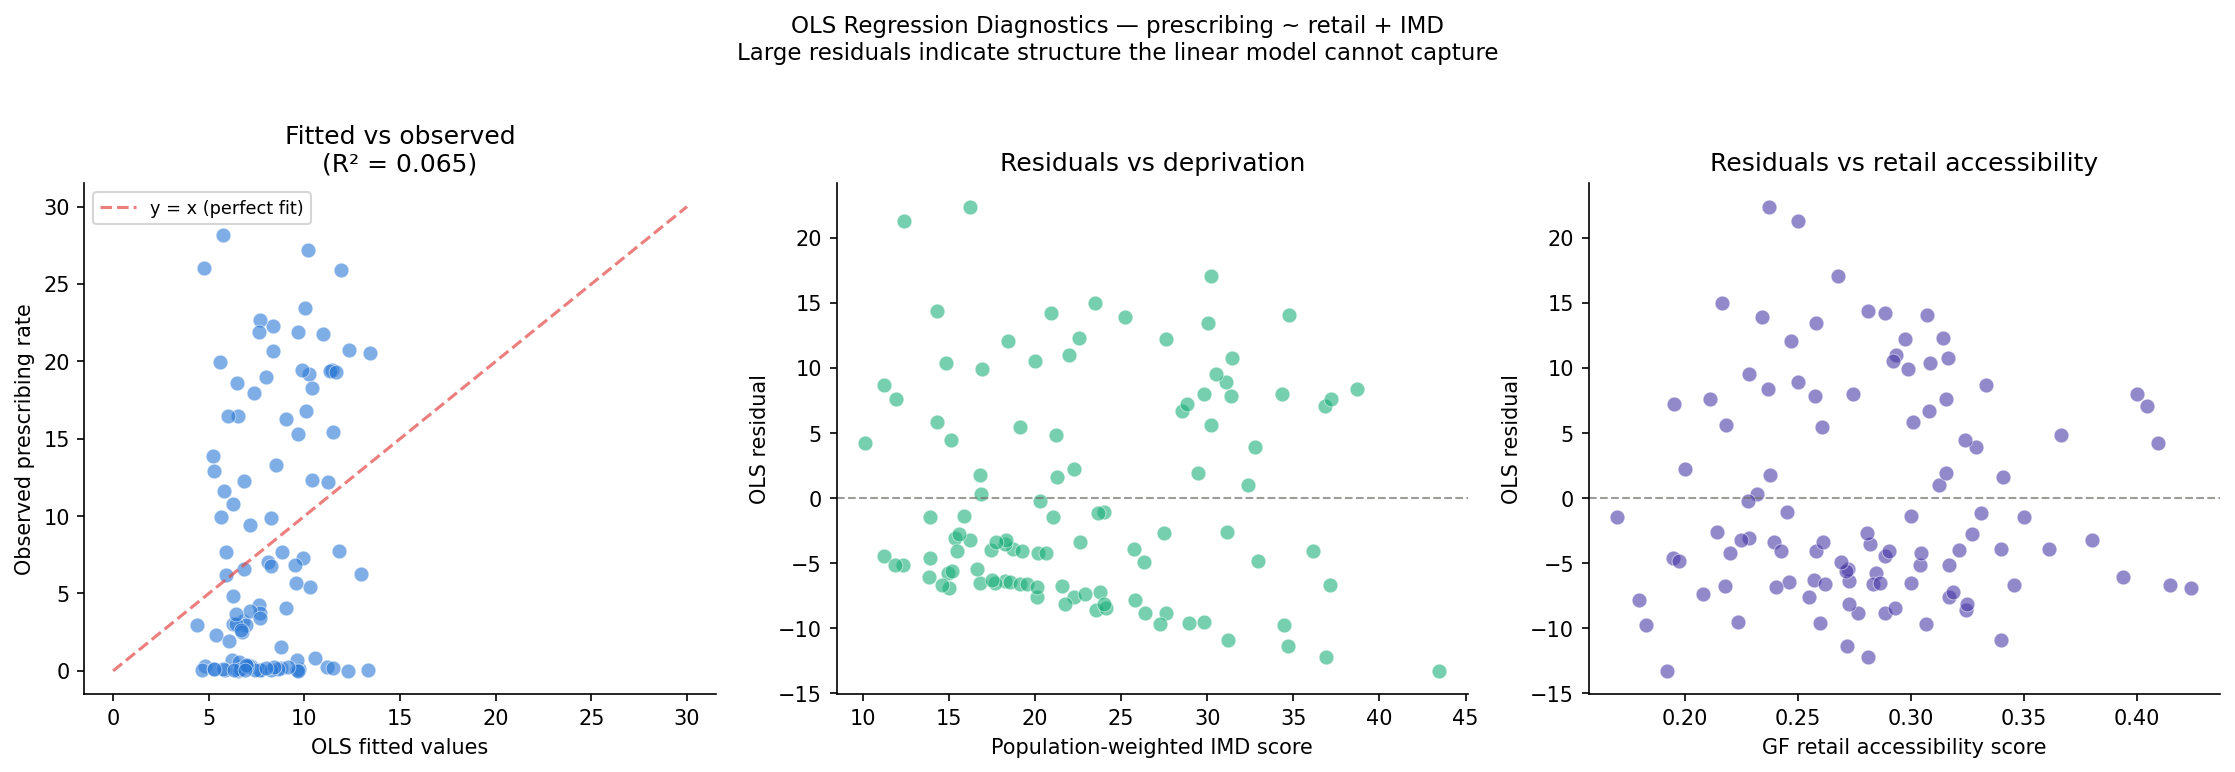

Saved CM_01. OLS results saved to outputs/tables/OLS_results.csv


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 2 — OLS REGRESSION
# Prescribing ~ retail accessibility + area deprivation
# Establishes linear baseline before Ball Mapper analysis
# ═══════════════════════════════════════════════════════════════════════════

y     = df['prescribing_rate_recent']
X_ols = sm.add_constant(df[['retail_accessibility_score',
                             'imd_score_weighted']])

model = sm.OLS(y, X_ols).fit()

print("="*60)
print("OLS REGRESSION: prescribing ~ retail + IMD")
print("="*60)
print(model.summary())

# Key results
print("\nKEY RESULTS:")
print(f"  R-squared:          {model.rsquared:.4f}")
print(f"  Adj. R-squared:     {model.rsquared_adj:.4f}")
print(f"  F-statistic:        {model.fvalue:.4f} (p={model.f_pvalue:.4f})")
print(f"  Retail coef:        {model.params['retail_accessibility_score']:.4f} "
      f"(p={model.pvalues['retail_accessibility_score']:.4f})")
print(f"  IMD coef:           {model.params['imd_score_weighted']:.4f} "
      f"(p={model.pvalues['imd_score_weighted']:.4f})")

# Save results
ols_results = pd.DataFrame({
    'variable':    ['const', 'retail_accessibility_score', 'imd_score_weighted'],
    'coef':        model.params.values.round(4),
    'std_err':     model.bse.values.round(4),
    't_stat':      model.tvalues.values.round(4),
    'p_value':     model.pvalues.values.round(4),
    'ci_lower':    model.conf_int()[0].values.round(4),
    'ci_upper':    model.conf_int()[1].values.round(4),
})
ols_results.to_csv(f'{TAB_PATH}/OLS_results.csv', index=False)

# Add fitted values and residuals to df
df['ols_fitted']   = model.fittedvalues
df['ols_residual'] = model.resid

# Diagnostics plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Fitted vs observed
axes[0].scatter(df['ols_fitted'], df['prescribing_rate_recent'],
                color=BLUE, alpha=0.6, s=50,
                edgecolors='white', linewidth=0.4)
axes[0].plot([0, 30], [0, 30], color=RED, linewidth=1.5,
             linestyle='--', alpha=0.7, label='y = x (perfect fit)')
axes[0].set_xlabel('OLS fitted values')
axes[0].set_ylabel('Observed prescribing rate')
axes[0].set_title(f'Fitted vs observed\n(R² = {model.rsquared:.3f})')
axes[0].legend(fontsize=8.5)

# Residuals vs IMD
axes[1].scatter(df['imd_score_weighted'], df['ols_residual'],
                color=GREEN, alpha=0.6, s=50,
                edgecolors='white', linewidth=0.4)
axes[1].axhline(0, color=GREY, linewidth=1, linestyle='--', alpha=0.7)
axes[1].set_xlabel('Population-weighted IMD score')
axes[1].set_ylabel('OLS residual')
axes[1].set_title('Residuals vs deprivation')

# Residuals vs retail
axes[2].scatter(df['retail_accessibility_score'], df['ols_residual'],
                color=PURPLE, alpha=0.6, s=50,
                edgecolors='white', linewidth=0.4)
axes[2].axhline(0, color=GREY, linewidth=1, linestyle='--', alpha=0.7)
axes[2].set_xlabel('GF retail accessibility score')
axes[2].set_ylabel('OLS residual')
axes[2].set_title('Residuals vs retail accessibility')

plt.suptitle('OLS Regression Diagnostics — prescribing ~ retail + IMD\n'
             'Large residuals indicate structure the linear model cannot capture',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/CM_01_OLS_diagnostics.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved CM_01. OLS results saved to outputs/tables/OLS_results.csv")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 3 — GLOBAL MORAN'S I
# Spatial autocorrelation of each variable using inverse distance weights
# Centroids computed from NSPL postcode coordinates
# ═══════════════════════════════════════════════════════════════════════════

# ── Compute Sub-ICB centroids from NSPL ───────────────────────────────────
print("Loading NSPL for Sub-ICB centroids...")
nspl = pd.read_csv(
    r'C:\Users\namra\gluten-free-spatial-inequality\data\raw\nspl_may2026.csv',
    usecols=['pcds', 'sicbl26cd', 'lat', 'long'],
    low_memory=False
)
nspl = nspl[nspl['sicbl26cd'].str.startswith('E', na=False)]

lookup = pd.read_csv(
    r'C:\Users\namra\gluten-free-spatial-inequality\data\raw\lsoa_to_sicbl_lookup.csv'
)
lookup_slim = lookup[['SICBL26CD', 'SICBL26CDH']].drop_duplicates()

centroids = nspl.groupby('sicbl26cd').agg(
    centroid_lat=('lat', 'mean'),
    centroid_lon=('long', 'mean')
).reset_index()

centroids = centroids.merge(
    lookup_slim,
    left_on='sicbl26cd', right_on='SICBL26CD', how='left'
).rename(columns={'SICBL26CDH': 'org_id'})

df = df.merge(centroids[['org_id', 'centroid_lat', 'centroid_lon']],
              on='org_id', how='left')

print(f"Centroids matched: {df[['centroid_lat','centroid_lon']].notna().all(axis=1).sum()} / {len(df)}")

# ── Build inverse distance weight matrix ──────────────────────────────────
coords      = df[['centroid_lat', 'centroid_lon']].values
dist_matrix = cdist(coords, coords, metric='euclidean')
np.fill_diagonal(dist_matrix, np.inf)
W           = 1 / dist_matrix
np.fill_diagonal(W, 0)
W_std       = W / W.sum(axis=1, keepdims=True)

# ── Moran's I function ────────────────────────────────────────────────────
def morans_i(values, W, n_perm=999):
    n   = len(values)
    z   = values - values.mean()
    num = n * np.sum(W * np.outer(z, z))
    den = np.sum(W) * np.sum(z**2)
    I   = num / den
    np.random.seed(42)
    I_perm = []
    for _ in range(n_perm):
        zp  = np.random.permutation(z)
        I_perm.append(n * np.sum(W * np.outer(zp, zp)) / den)
    I_perm  = np.array(I_perm)
    p_value = (np.sum(I_perm >= I) + 1) / (n_perm + 1)
    z_score = (I - I_perm.mean()) / I_perm.std()
    return I, z_score, p_value, I_perm

# ── Compute Moran's I for all four variables ──────────────────────────────
variables_morans = {
    'NHS GF Prescribing Rate':     df['prescribing_rate_recent'].values,
    'GF Retail Accessibility':     df['retail_accessibility_score'].values,
    'Area Deprivation (IMD)':      df['imd_score_weighted'].values,
    'Months Zero (Withdrawal)':    df['months_zero'].values,
}

morans_results = {}
print("\nGlobal Moran's I Results:")
print("="*60)
print(f"{'Variable':<30} {'I':>8} {'z':>8} {'p':>8} {'Sig':>5}")
print("-"*60)

for name, vals in variables_morans.items():
    I, z, p, I_perm = morans_i(vals, W_std)
    morans_results[name] = {'I': I, 'z': z, 'p': p, 'I_perm': I_perm}
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f"{name:<30} {I:>8.4f} {z:>8.3f} {p:>8.4f} {sig:>5}")

print("\n* p<0.05  ** p<0.01  *** p<0.001")
print("Moran's I > 0 = geographic clustering, I ≈ 0 = random")

# ── Save results ──────────────────────────────────────────────────────────
morans_df = pd.DataFrame([
    {'variable': k, 'morans_I': round(v['I'], 4),
     'z_score': round(v['z'], 4), 'p_value': round(v['p'], 4)}
    for k, v in morans_results.items()
])
morans_df.to_csv(f'{TAB_PATH}/morans_i_results.csv', index=False)

# ── Permutation distribution plots ────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors_m  = [BLUE, PURPLE, GREEN, AMBER]

for ax, (name, res), color in zip(axes, morans_results.items(), colors_m):
    I_perm = res['I_perm']
    I_obs  = res['I']
    ax.hist(I_perm, bins=40, color=color, alpha=0.6,
            edgecolor='white', linewidth=0.3)
    ax.axvline(I_obs, color=RED, linewidth=2, linestyle='-',
               label=f"Observed I = {I_obs:.4f}")
    ax.axvline(I_perm.mean(), color=GREY, linewidth=1,
               linestyle='--', alpha=0.7,
               label=f"Expected I = {I_perm.mean():.4f}")
    sig = '**' if res['p'] < 0.01 else ('*' if res['p'] < 0.05 else '')
    ax.set_title(f"{name}\nI = {I_obs:.4f}, p = {res['p']:.4f} {sig}",
                 fontsize=9)
    ax.set_xlabel("Moran's I (permutation distribution)")
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7.5)

plt.suptitle("Global Moran's I — Permutation Test Results (999 permutations)\n"
             "All variables show significant but weak geographic clustering",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/CM_02_morans_i.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("\nSaved CM_02. Moran's I results saved to outputs/tables/morans_i_results.csv")

Loading NSPL for Sub-ICB centroids...


  File "C:\Users\namra\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\namra\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\namra\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\namra\anaconda3\Lib\subprocess.

ARI between k-means (k=12) and Ball Mapper (ε=1.5): 0.3067

K-means cluster summary (k=12):
 Cluster  Areas    Presc   Retail     IMD   Mths0    Slope
------------------------------------------------------------
  KM0       20      1.3    0.290    16.6     6.2  -0.0460
  KM1        8     18.2    0.308    31.4     0.0   0.0620
  KM2        6      2.3    0.198    32.9    17.8  -0.0580
  KM3        8     21.5    0.275    18.3     0.0   0.0500
  KM4        9      1.4    0.278    26.0     4.8  -0.1310
  KM5        7     13.5    0.306    14.8     0.4  -0.0490
  KM6       16      3.4    0.224    19.2     3.2  -0.0370
  KM7       11     20.4    0.234    30.6     0.0   0.0440
  KM8        5      3.0    0.405    13.9     4.6   0.0080
  KM9        5      2.9    0.299    35.2    10.4  -0.0900
  KM10       2     19.9    0.402    33.3     0.0   0.0750
  KM11       9      5.4    0.340    22.3     4.7   0.0040


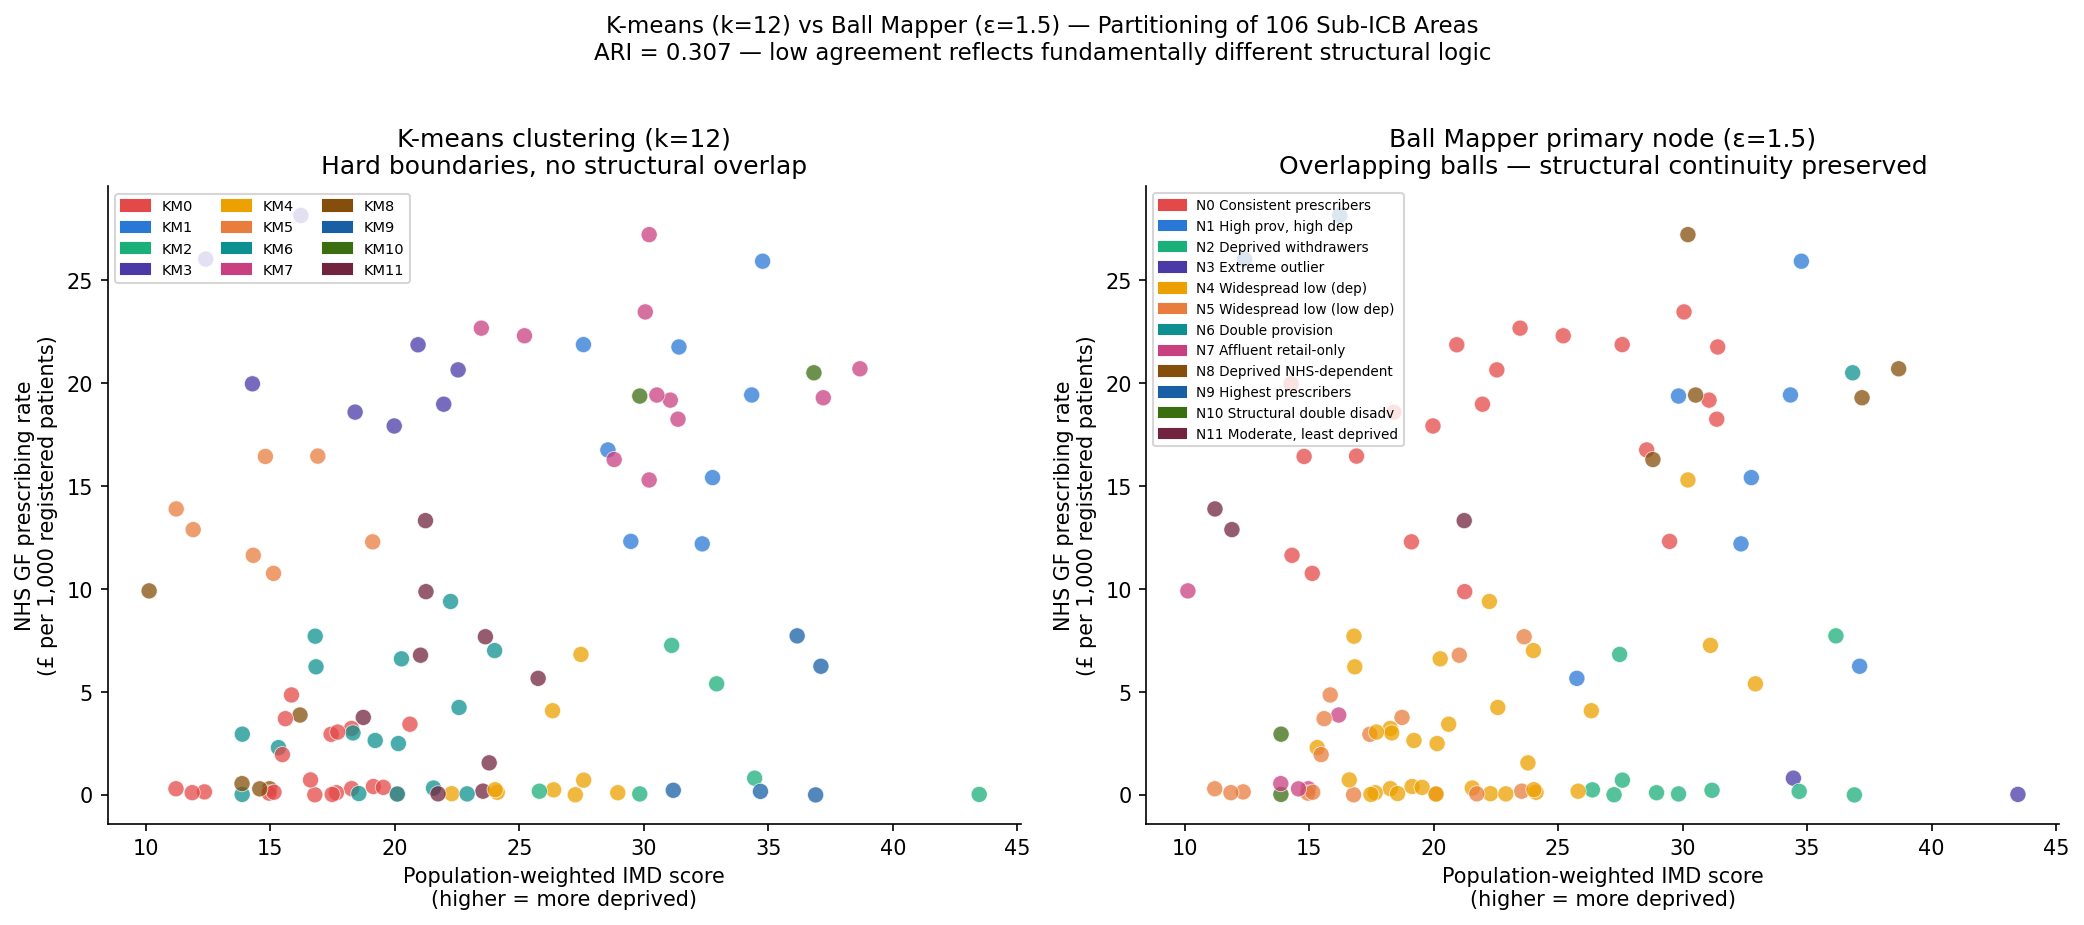

Saved CM_03.


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 4 — K-MEANS CLUSTERING (k=12)
# Same 3D scaled space as Ball Mapper
# k=12 matches Ball Mapper node count for direct comparison
# ═══════════════════════════════════════════════════════════════════════════

# Run k-means
kmeans    = KMeans(n_clusters=N_NODES_BM, random_state=42, n_init=50)
km_labels = kmeans.fit_predict(X_scaled)
df['kmeans_cluster'] = km_labels

# ARI between k-means and Ball Mapper
ari_km = adjusted_rand_score(bm_labels, km_labels)
print(f"ARI between k-means (k={N_NODES_BM}) and Ball Mapper (ε=1.5): {ari_km:.4f}")

# K-means cluster summary
km_summary = df.groupby('kmeans_cluster').agg(
    areas                  = ('org_id', 'count'),
    mean_prescribing       = ('prescribing_rate_recent', 'mean'),
    mean_retail            = ('retail_accessibility_score', 'mean'),
    mean_imd               = ('imd_score_weighted', 'mean'),
    mean_months_zero       = ('months_zero', 'mean'),
    mean_slope             = ('trend_slope', 'mean')
).round(3)

print(f"\nK-means cluster summary (k={N_NODES_BM}):")
print(f"{'Cluster':>8} {'Areas':>6} {'Presc':>8} {'Retail':>8} "
      f"{'IMD':>7} {'Mths0':>7} {'Slope':>8}")
print("-" * 60)
for idx, row in km_summary.iterrows():
    print(f"  KM{idx:<4} {int(row['areas']):>5} {row['mean_prescribing']:>8.1f} "
          f"{row['mean_retail']:>8.3f} {row['mean_imd']:>7.1f} "
          f"{row['mean_months_zero']:>7.1f} {row['mean_slope']:>8.4f}")

km_summary.to_csv(f'{TAB_PATH}/kmeans_cluster_summary.csv')

# ── Comparison scatter plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-means colours
km_colors = [
    '#e34948','#2a78d6','#1baf7a','#4a3aa7','#eda100',
    '#e87d3e','#0f9090','#c94080','#854F0B','#185FA5',
    '#3B6D11','#72243E'
]
km_color_vals = [km_colors[c] for c in df['kmeans_cluster']]

axes[0].scatter(df['imd_score_weighted'],
                df['prescribing_rate_recent'],
                c=km_color_vals, alpha=0.75, s=60,
                edgecolors='white', linewidth=0.4)
axes[0].set_xlabel('Population-weighted IMD score\n(higher = more deprived)')
axes[0].set_ylabel('NHS GF prescribing rate\n(£ per 1,000 registered patients)')
axes[0].set_title(f'K-means clustering (k={N_NODES_BM})\n'
                  f'Hard boundaries, no structural overlap')
handles_km = [mpatches.Patch(color=km_colors[i], label=f'KM{i}')
              for i in range(N_NODES_BM)]
axes[0].legend(handles=handles_km, fontsize=7, ncol=3,
               loc='upper left')

# Ball Mapper primary node colours
bm_colors_list = [
    '#e34948','#2a78d6','#1baf7a','#4a3aa7','#eda100',
    '#e87d3e','#0f9090','#c94080','#854F0B','#185FA5',
    '#3B6D11','#72243E'
]
node_labels_short = {
    0: 'N0 Consistent prescribers',
    1: 'N1 High prov, high dep',
    2: 'N2 Deprived withdrawers',
    3: 'N3 Extreme outlier',
    4: 'N4 Widespread low (dep)',
    5: 'N5 Widespread low (low dep)',
    6: 'N6 Double provision',
    7: 'N7 Affluent retail-only',
    8: 'N8 Deprived NHS-dependent',
    9: 'N9 Highest prescribers',
    10: 'N10 Structural double disadv',
    11: 'N11 Moderate, least deprived',
}
bm_color_vals = [bm_colors_list[l] if l >= 0 else '#cccccc'
                 for l in bm_labels]

axes[1].scatter(df['imd_score_weighted'],
                df['prescribing_rate_recent'],
                c=bm_color_vals, alpha=0.75, s=60,
                edgecolors='white', linewidth=0.4)
axes[1].set_xlabel('Population-weighted IMD score\n(higher = more deprived)')
axes[1].set_ylabel('NHS GF prescribing rate\n(£ per 1,000 registered patients)')
axes[1].set_title(f'Ball Mapper primary node (ε=1.5)\n'
                  f'Overlapping balls — structural continuity preserved')
handles_bm = [mpatches.Patch(color=bm_colors_list[i],
                              label=node_labels_short[i])
              for i in range(N_NODES_BM)]
axes[1].legend(handles=handles_bm, fontsize=6.5, ncol=1,
               loc='upper left')

plt.suptitle(
    f'K-means (k={N_NODES_BM}) vs Ball Mapper (ε=1.5) — '
    f'Partitioning of 106 Sub-ICB Areas\n'
    f'ARI = {ari_km:.3f} — low agreement reflects '
    f'fundamentally different structural logic',
    fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/CM_03_kmeans_vs_ballmapper.png',
            bbox_inches='tight', dpi=150)
plt.show()
print(f"Saved CM_03.")

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 15)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette={score:.4f}")

optimal_k = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nOptimal k by silhouette: {optimal_k}")

In [6]:
# ── K-MEANS CLUSTERING ────────────────────────────────────────────────────
# k=7 in same 3D scaled space as Ball Mapper
# Direct comparison of cluster membership vs Ball Mapper nodes

from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
import networkx as nx

# Rebuild Ball Mapper for comparison
def ball_mapper(X, epsilon):
    n = X.shape[0]
    dist = euclidean_distances(X)
    covered = np.zeros(n, dtype=bool)
    nodes = {}
    nid = 0
    for i in range(n):
        if not covered[i]:
            members = np.where(dist[i] <= epsilon)[0].tolist()
            nodes[nid] = members
            for j in members:
                covered[j] = True
            nid += 1
    edges = []
    ids = list(nodes.keys())
    for a in range(len(ids)):
        for b in range(a + 1, len(ids)):
            if set(nodes[ids[a]]) & set(nodes[ids[b]]):
                edges.append((ids[a], ids[b]))
    return nodes, edges

def primary_node_partition(nodes, n_points):
    labels = np.full(n_points, -1)
    for nid, members in nodes.items():
        for m in members:
            if labels[m] == -1:
                labels[m] = nid
    return labels

variables = ['prescribing_rate_recent', 'retail_accessibility_score', 'imd_score_weighted']
X_raw    = df[variables].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

nodes, edges = ball_mapper(X_scaled, 2.0)
bm_labels = primary_node_partition(nodes, len(df))

# K-means with k=7
kmeans = KMeans(n_clusters=7, random_state=42, n_init=50)
km_labels = kmeans.fit_predict(X_scaled)

# ARI between k-means and Ball Mapper
ari_km_bm = adjusted_rand_score(bm_labels, km_labels)
print(f"ARI between k-means (k=7) and Ball Mapper (ε=2.0): {ari_km_bm:.4f}")

# K-means cluster summary
df['kmeans_cluster'] = km_labels
km_summary = df.groupby('kmeans_cluster').agg(
    areas=('org_id', 'count'),
    mean_prescribing=('prescribing_rate_recent', 'mean'),
    mean_retail=('retail_accessibility_score', 'mean'),
    mean_imd=('imd_score_weighted', 'mean'),
    mean_months_zero=('months_zero', 'mean'),
    mean_slope=('trend_slope', 'mean')
).round(3)

print("\nK-means cluster summary (k=7):")
print(km_summary.to_string())

km_summary.to_csv(f'{TAB_PATH}/kmeans_cluster_summary.csv')
print("\nSaved k-means summary.")

  File "C:\Users\namra\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\namra\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\namra\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\namra\anaconda3\Lib\subprocess.

ARI between k-means (k=7) and Ball Mapper (ε=2.0): 0.2592

K-means cluster summary (k=7):
                areas  mean_prescribing  mean_retail  mean_imd  mean_months_zero  mean_slope
kmeans_cluster                                                                              
0                  15             2.244        0.256    31.645            13.000      -0.094
1                  15            17.774        0.290    16.674             0.200       0.004
2                  14            20.815        0.247    30.963             0.000       0.072
3                  25             1.125        0.294    17.970             6.680      -0.052
4                  11             5.640        0.374    18.306             2.091       0.008
5                  18             3.076        0.223    19.704             3.278      -0.033
6                   8            15.576        0.342    32.291             0.000      -0.008

Saved k-means summary.


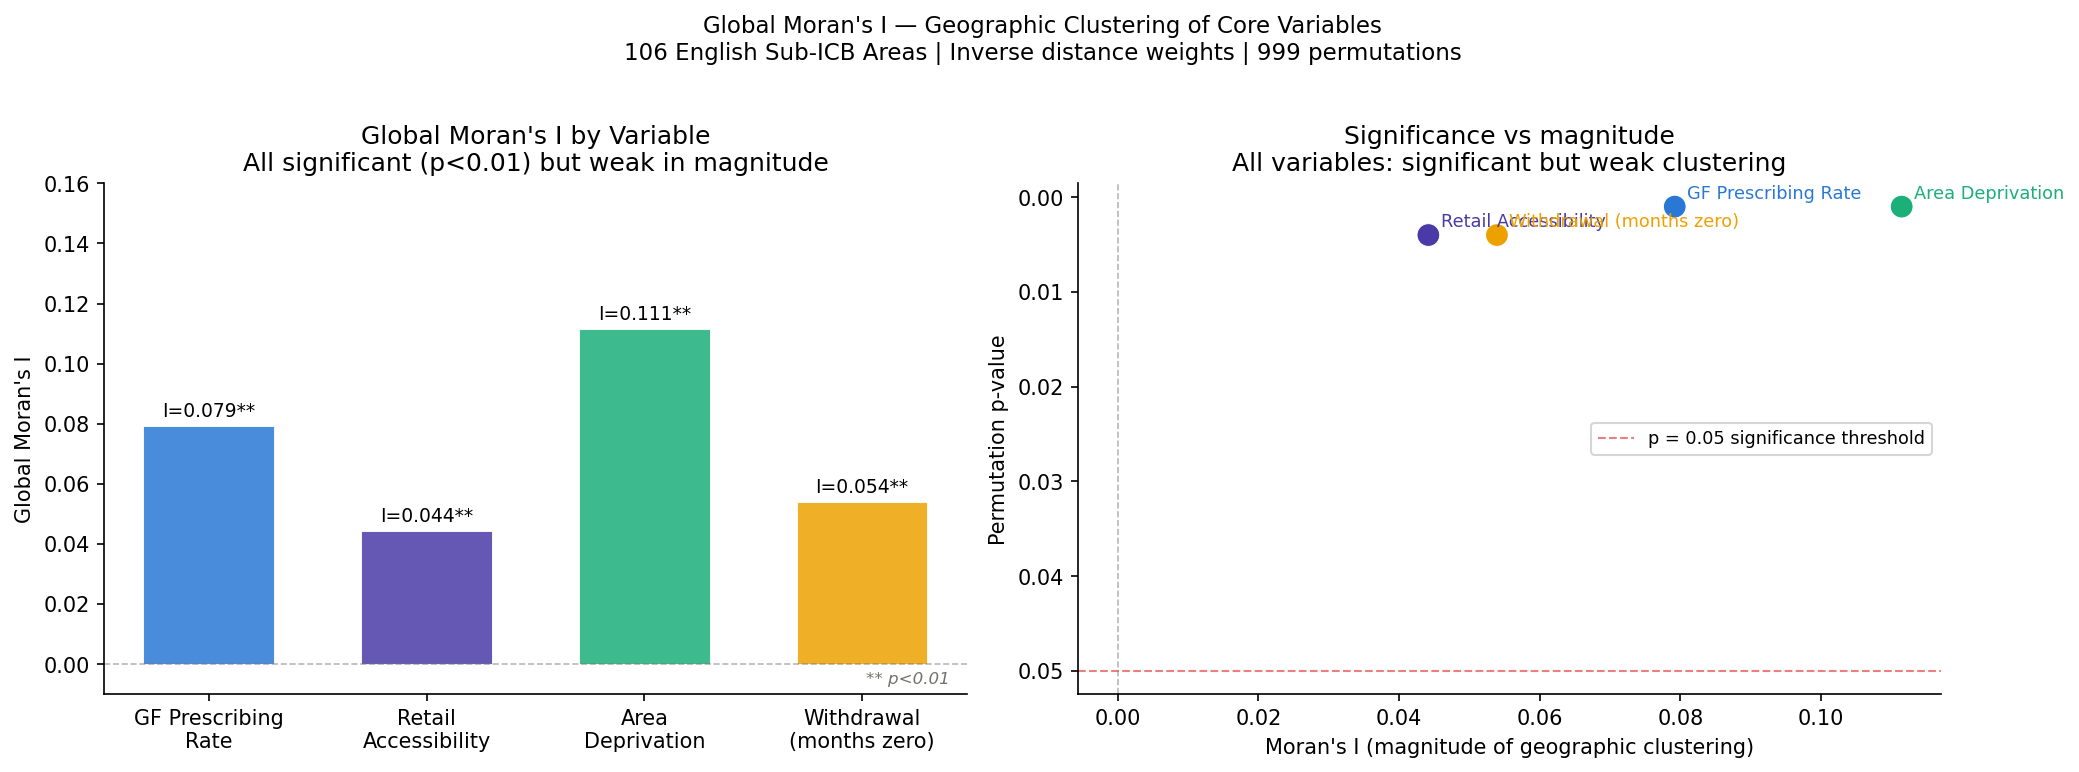


Moran's I Summary Table:
Variable                                I   z-score   p-value   Sig
-----------------------------------------------------------------
NHS GF Prescribing Rate            0.0792     5.874    0.0010    **
GF Retail Accessibility            0.0442     3.552    0.0040    **
Area Deprivation (IMD)             0.1115     8.248    0.0010    **
Months Zero (Withdrawal)           0.0539     4.390    0.0040    **
-----------------------------------------------------------------
** p<0.01  * p<0.05

Key finding: all variables show statistically significant positive
spatial autocorrelation but weak in magnitude (all I < 0.12).
Geographic space partially organises the data but does not determine it.
Ball Mapper, operating in variable space, captures structure
that geographic clustering analysis cannot reveal.
Saved CM_02b.


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 5 — MORAN'S I SUMMARY VISUAL
# Clean comparison of geographic clustering across all four variables
# ═══════════════════════════════════════════════════════════════════════════

# ── Summary bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

var_names  = list(morans_results.keys())
I_values   = [morans_results[v]['I'] for v in var_names]
p_values   = [morans_results[v]['p'] for v in var_names]
colors_bar = [BLUE, PURPLE, GREEN, AMBER]
short_names = ['GF Prescribing\nRate', 'Retail\nAccessibility',
               'Area\nDeprivation', 'Withdrawal\n(months zero)']

bars = axes[0].bar(short_names, I_values, color=colors_bar,
                   alpha=0.85, edgecolor='white', linewidth=0.5,
                   width=0.6)

for bar, val, p in zip(bars, I_values, p_values):
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else '')
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.002,
                 f'I={val:.3f}{sig}',
                 ha='center', va='bottom', fontsize=9, fontweight='500')

axes[0].axhline(0, color=GREY, linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].set_ylabel("Global Moran's I")
axes[0].set_title("Global Moran's I by Variable\n"
                  "All significant (p<0.01) but weak in magnitude")
axes[0].set_ylim(-0.01, 0.16)
axes[0].text(0.98, 0.02, '** p<0.01',
             transform=axes[0].transAxes,
             ha='right', fontsize=8, color=GREY, style='italic')

# ── Interpretation scatter: I vs p-value ──────────────────────────────────
axes[1].scatter(I_values, p_values, c=colors_bar, s=120,
                edgecolors='white', linewidth=0.5, zorder=3)
axes[1].axhline(0.05, color=RED, linewidth=1, linestyle='--',
                alpha=0.7, label='p = 0.05 significance threshold')
axes[1].axvline(0, color=GREY, linewidth=0.8, linestyle='--', alpha=0.5)

for name, I, p, color in zip(short_names, I_values, p_values, colors_bar):
    axes[1].annotate(name.replace('\n', ' '),
                     xy=(I, p), xytext=(6, 4),
                     textcoords='offset points',
                     fontsize=8.5, color=color)

axes[1].set_xlabel("Moran's I (magnitude of geographic clustering)")
axes[1].set_ylabel('Permutation p-value')
axes[1].set_title("Significance vs magnitude\nAll variables: significant but weak clustering")
axes[1].legend(fontsize=8.5)
axes[1].invert_yaxis()

plt.suptitle("Global Moran's I — Geographic Clustering of Core Variables\n"
             "106 English Sub-ICB Areas | Inverse distance weights | "
             "999 permutations",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/CM_02b_morans_summary.png',
            bbox_inches='tight', dpi=150)
plt.show()

# ── Clean summary table ───────────────────────────────────────────────────
print("\nMoran's I Summary Table:")
print("="*65)
print(f"{'Variable':<32} {'I':>8} {'z-score':>9} {'p-value':>9} {'Sig':>5}")
print("-"*65)
interp = {
    'NHS GF Prescribing Rate':   'Weak-moderate clustering',
    'GF Retail Accessibility':   'Weak clustering',
    'Area Deprivation (IMD)':    'Weak-moderate clustering',
    'Months Zero (Withdrawal)':  'Weak clustering',
}
for name in var_names:
    res = morans_results[name]
    sig = '**' if res['p'] < 0.01 else ('*' if res['p'] < 0.05 else '')
    print(f"{name:<32} {res['I']:>8.4f} {res['z']:>9.3f} "
          f"{res['p']:>9.4f} {sig:>5}")
print("-"*65)
print("** p<0.01  * p<0.05")
print("\nKey finding: all variables show statistically significant positive")
print("spatial autocorrelation but weak in magnitude (all I < 0.12).")
print("Geographic space partially organises the data but does not determine it.")
print("Ball Mapper, operating in variable space, captures structure")
print("that geographic clustering analysis cannot reveal.")
print("Saved CM_02b.")

N3 ISOLATED CLUSTER — Does k-means identify it?
  Blackpool    → k-means cluster KM2
  Leicester City → k-means cluster KM2
  Both in same k-means cluster (KM2) with 6 areas:
    BLACKPOOL
    HALTON
    ROTHERHAM
    LEICESTER CITY
    STOKE ON TRENT
    KIRKLEES


K-MEANS vs BALL MAPPER — NODE FRAGMENTATION ANALYSIS
For each Ball Mapper node: which k-means clusters contain its members?
-----------------------------------------------------------------

  N0 — Consistent prescribers (21 areas)
    → Split across 5 k-means clusters:
       KM3: 6 areas
       KM7: 5 areas
       KM5: 5 areas
       KM1: 4 areas
       KM11: 1 areas

  N1 — High prov, high dep (12 areas)
    → Split across 5 k-means clusters:
       KM1: 8 areas
       KM10: 1 areas
       KM7: 1 areas
       KM11: 1 areas
       KM9: 1 areas

  N2 — Deprived withdrawers (11 areas)
    → Split across 3 k-means clusters:
       KM9: 5 areas
       KM4: 5 areas
       KM2: 1 areas

  N3 — Extreme outlier (ISOLATED) (2 area

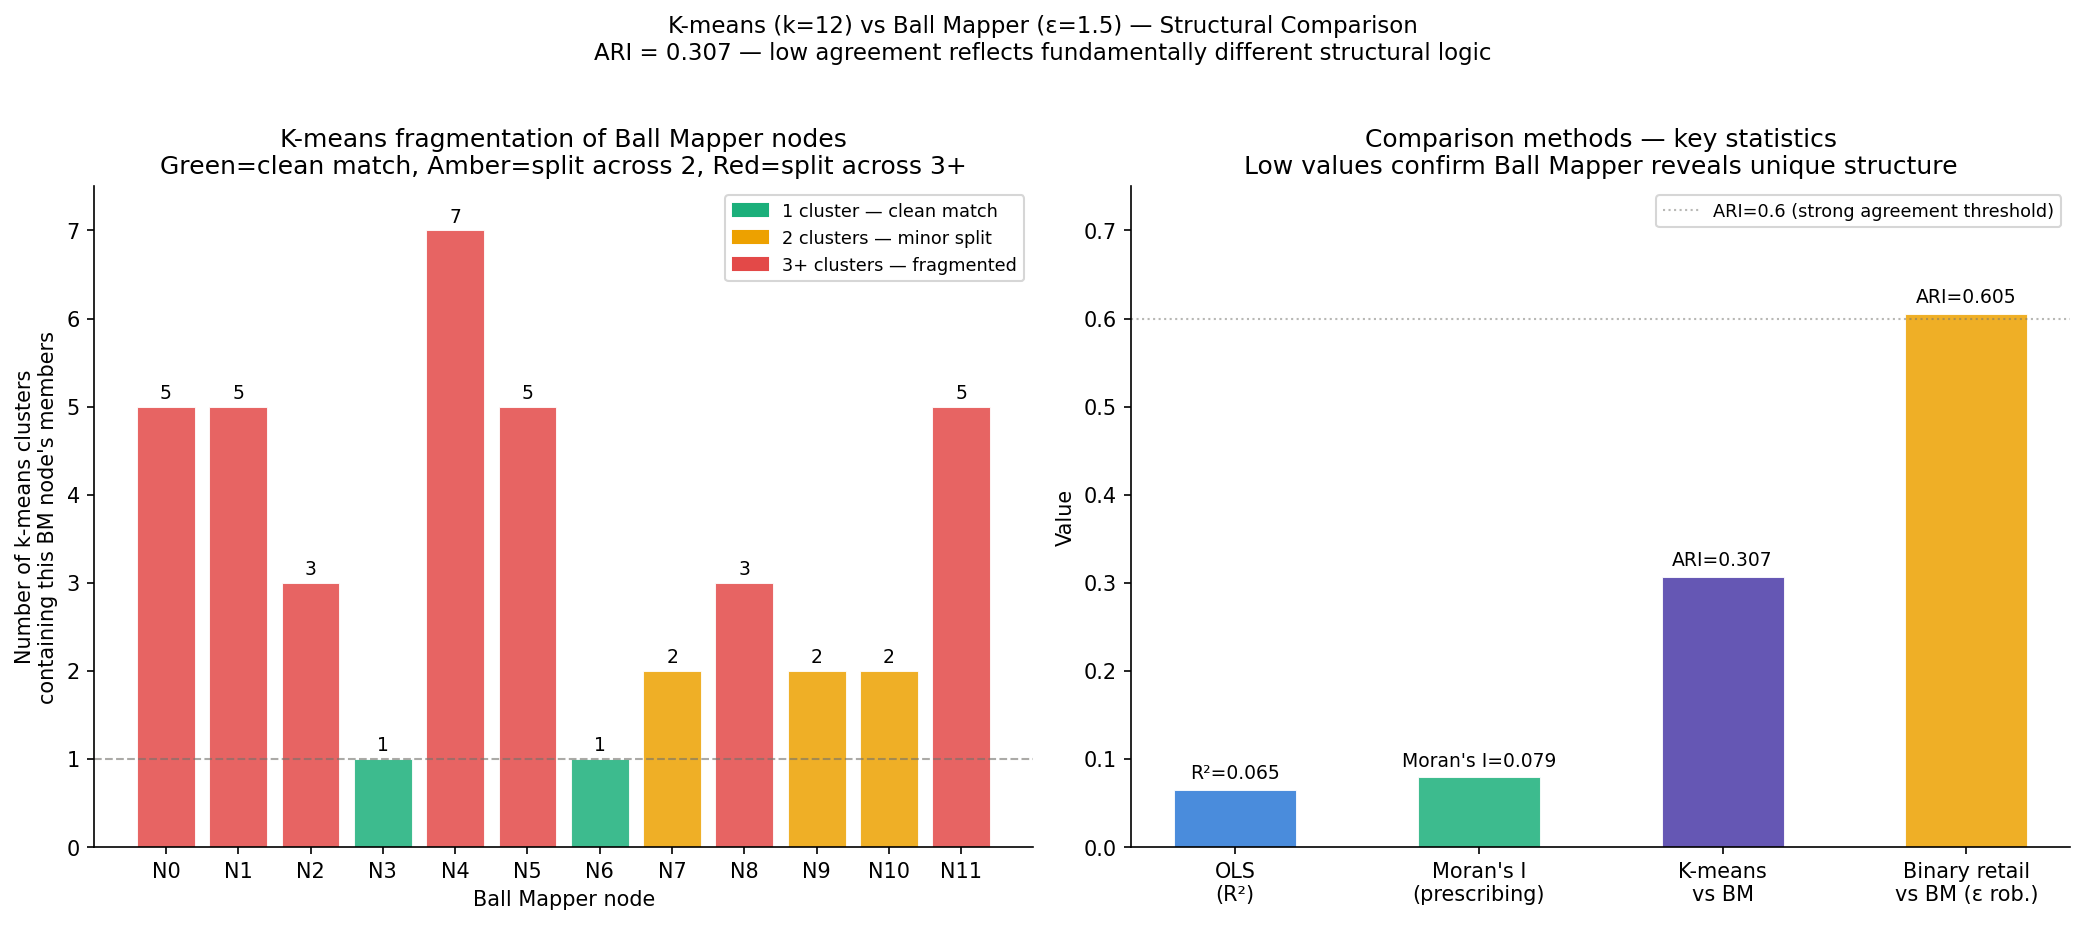

Saved CM_03b.


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 6 — K-MEANS VS BALL MAPPER DETAILED COMPARISON
# What each method finds and what it misses
# ═══════════════════════════════════════════════════════════════════════════

# ── Does k-means identify N3 (Blackpool + Leicester City)? ────────────────
blackpool_idx     = df[df['org_name'].str.contains('BLACKPOOL')].index[0]
leicester_idx     = df[df['org_name'].str.contains('LEICESTER CITY')].index[0]
blackpool_cluster = df.loc[blackpool_idx, 'kmeans_cluster']
leicester_cluster = df.loc[leicester_idx, 'kmeans_cluster']

print("N3 ISOLATED CLUSTER — Does k-means identify it?")
print(f"  Blackpool    → k-means cluster KM{blackpool_cluster}")
print(f"  Leicester City → k-means cluster KM{leicester_cluster}")
if blackpool_cluster == leicester_cluster:
    cluster_members = df[df['kmeans_cluster'] == blackpool_cluster]['org_name'].tolist()
    print(f"  Both in same k-means cluster (KM{blackpool_cluster}) "
          f"with {len(cluster_members)} areas:")
    for a in cluster_members:
        print(f"    {a.replace('NHS ','')}")
else:
    print(f"  K-means separates Blackpool and Leicester City "
          f"into different clusters")

# ── Which BM nodes does k-means fragment or merge? ────────────────────────
print("\n\nK-MEANS vs BALL MAPPER — NODE FRAGMENTATION ANALYSIS")
print("="*65)
print("For each Ball Mapper node: which k-means clusters contain its members?")
print("-"*65)

node_labels_short2 = {
    0: 'Consistent prescribers',
    1: 'High prov, high dep',
    2: 'Deprived withdrawers',
    3: 'Extreme outlier (ISOLATED)',
    4: 'Widespread low prov (dep)',
    5: 'Widespread low prov (less dep)',
    6: 'Double provision outlier',
    7: 'Affluent retail-only',
    8: 'Deprived NHS-dependent',
    9: 'Highest prescribers',
    10: 'Structural double disadv',
    11: 'Moderate, least deprived',
}

# Rebuild BM node membership from bm_labels
bm_node_to_km = {}
for nid, members in nodes_bm.items():
    km_assignments = [df['kmeans_cluster'].iloc[m] for m in members]
    km_counts      = pd.Series(km_assignments).value_counts()
    bm_node_to_km[nid] = km_counts

for nid in sorted(nodes_bm.keys()):
    km_dist = bm_node_to_km[nid]
    n_km    = len(km_dist)
    label   = node_labels_short2[nid]
    print(f"\n  N{nid} — {label} ({len(nodes_bm[nid])} areas)")
    if n_km == 1:
        print(f"    → All in KM{km_dist.index[0]} ✓ (clean match)")
    else:
        print(f"    → Split across {n_km} k-means clusters:")
        for km_id, count in km_dist.items():
            print(f"       KM{km_id}: {count} areas")

# ── Key structural comparison: N2 vs N8 ───────────────────────────────────
print("\n\nCRITICAL STRUCTURAL COMPARISON: N2 vs N8")
print("="*65)
print("N2 (Deprived withdrawers) and N8 (Deprived NHS-dependent)")
print("are connected by an edge in Ball Mapper — structurally adjacent.")
print("How does k-means handle them?\n")

n2_members = nodes_bm[2]
n8_members = nodes_bm[8]
n2_km      = [df['kmeans_cluster'].iloc[m] for m in n2_members]
n8_km      = [df['kmeans_cluster'].iloc[m] for m in n8_members]
overlap_km = set(n2_km) & set(n8_km)

print(f"  N2 members assigned to k-means clusters: {sorted(set(n2_km))}")
print(f"  N8 members assigned to k-means clusters: {sorted(set(n8_km))}")
print(f"  Shared k-means clusters: {sorted(overlap_km) if overlap_km else 'None'}")
if not overlap_km:
    print(f"  → K-means places N2 and N8 in entirely separate clusters.")
    print(f"     The structural adjacency revealed by Ball Mapper is")
    print(f"     invisible to k-means hard boundary assignment.")
else:
    print(f"  → K-means partially overlaps N2 and N8 in {len(overlap_km)} cluster(s).")

# ── Summary comparison figure ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: k-means fragmentation — how many k-means clusters per BM node
n_km_clusters_per_bm = [len(bm_node_to_km[nid]) for nid in sorted(nodes_bm.keys())]
node_ids = [f"N{nid}" for nid in sorted(nodes_bm.keys())]
colors_frag = [RED if n > 2 else AMBER if n == 2 else GREEN
               for n in n_km_clusters_per_bm]

bars = axes[0].bar(node_ids, n_km_clusters_per_bm,
                   color=colors_frag, alpha=0.85,
                   edgecolor='white', linewidth=0.5)
axes[0].axhline(1, color=GREY, linewidth=1, linestyle='--',
                alpha=0.6, label='Perfect match (1 k-means cluster)')
for bar, val in zip(bars, n_km_clusters_per_bm):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 0.05, str(val),
                 ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('Number of k-means clusters\ncontaining this BM node\'s members')
axes[0].set_xlabel('Ball Mapper node')
axes[0].set_title('K-means fragmentation of Ball Mapper nodes\n'
                  'Green=clean match, Amber=split across 2, Red=split across 3+')
axes[0].legend(fontsize=8.5)
axes[0].set_ylim(0, max(n_km_clusters_per_bm) + 0.5)

handles_leg = [
    mpatches.Patch(color=GREEN, label='1 cluster — clean match'),
    mpatches.Patch(color=AMBER, label='2 clusters — minor split'),
    mpatches.Patch(color=RED,   label='3+ clusters — fragmented'),
]
axes[0].legend(handles=handles_leg, fontsize=8.5)

# Right: ARI comparison across methods
methods = ['OLS\n(R²)', "Moran's I\n(prescribing)",
           'K-means\nvs BM', 'Binary retail\nvs BM (ε rob.)']
values  = [0.065, 0.0792, ari_km, 0.6054]
colors_comp = [BLUE, GREEN, PURPLE, AMBER]
note    = ['R²', 'Moran\'s I', 'ARI', 'ARI']

bars2 = axes[1].bar(methods, values, color=colors_comp,
                    alpha=0.85, edgecolor='white', linewidth=0.5,
                    width=0.5)
for bar, val, n in zip(bars2, values, note):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 0.008, f'{n}={val:.3f}',
                 ha='center', va='bottom', fontsize=9, fontweight='500')
axes[1].set_ylabel('Value')
axes[1].set_title('Comparison methods — key statistics\n'
                  'Low values confirm Ball Mapper reveals unique structure')
axes[1].set_ylim(0, 0.75)
axes[1].axhline(0.6, color=GREY, linewidth=1, linestyle=':',
                alpha=0.5, label='ARI=0.6 (strong agreement threshold)')
axes[1].legend(fontsize=8.5)

plt.suptitle(f'K-means (k={N_NODES_BM}) vs Ball Mapper (ε=1.5) — '
             f'Structural Comparison\n'
             f'ARI = {ari_km:.3f} — low agreement reflects '
             f'fundamentally different structural logic',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/CM_03b_kmeans_bm_comparison.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved CM_03b.")

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 7 — COMPARISON METHODS SUMMARY TABLE
# Single clean table summarising all comparison method findings
# ═══════════════════════════════════════════════════════════════════════════

summary_data = [
    {
        'Method': 'OLS Regression',
        'Question addressed': 'Is prescribing linearly predicted by retail and IMD?',
        'Key statistic': 'R² = 0.065',
        'Result': 'Not significant for retail (p=0.519); IMD weakly significant (p=0.009)',
        'What it cannot do': 'Cannot detect non-linear or heterogeneous structure; treats 106 areas as homogeneous population',
        'Ball Mapper adds': 'Reveals that high-IMD areas split into N2 (withdrawers) and N8 (NHS-dependent) — opposite behaviours OLS averages into one slope'
    },
    {
        'Method': "Global Moran's I",
        'Question addressed': 'Are variables geographically clustered in physical space?',
        'Key statistic': 'I = 0.044–0.112 (all p<0.01)',
        'Result': 'All four variables significantly but weakly clustered geographically',
        'What it cannot do': 'Operates in geographic space only; cannot identify variable-space clusters across multiple dimensions simultaneously',
        'Ball Mapper adds': 'Identifies structural clusters of areas sharing similar profiles across all three axes regardless of geographic proximity'
    },
    {
        'Method': 'K-means (k=12)',
        'Question addressed': 'What partition does conventional variable-space clustering find?',
        'Key statistic': f'ARI vs Ball Mapper = {ari_km:.3f}',
        'Result': 'Low agreement with Ball Mapper; most BM nodes split across 2–7 k-means clusters',
        'What it cannot do': 'Imposes hard convex boundaries; cannot represent structural overlap or continuity between groups',
        'Ball Mapper adds': 'Overlapping node membership preserves continuity between N2 and N8 — structurally adjacent despite opposite prescribing trajectories'
    },
    {
        'Method': 'TopoTests (ECC)',
        'Question addressed': 'Does the global topology of the point cloud deviate from null?',
        'Key statistic': 'p = TBC',
        'Result': 'TBC — running in Cell 8',
        'What it cannot do': '1-skeleton approximation may lack power at n=106; tests global not local topology',
        'Ball Mapper adds': 'Reveals local structural clusters (e.g. isolated N3) that global ECC test cannot detect'
    },
]

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(f'{TAB_PATH}/comparison_methods_summary.csv', index=False)

# Print clean version
print("COMPARISON METHODS SUMMARY")
print("="*80)
for _, row in summary_df.iterrows():
    print(f"\n{row['Method']}")
    print(f"  Question:    {row['Question addressed']}")
    print(f"  Key stat:    {row['Key statistic']}")
    print(f"  Result:      {row['Result']}")
    print(f"  Cannot do:   {row['What it cannot do']}")
    print(f"  BM adds:     {row['Ball Mapper adds']}")

print("\nSaved comparison_methods_summary.csv")
print("\nNote: TopoTests p-value will be updated after Cell 8.")

COMPARISON METHODS SUMMARY

OLS Regression
  Question:    Is prescribing linearly predicted by retail and IMD?
  Key stat:    R² = 0.065
  Result:      Not significant for retail (p=0.519); IMD weakly significant (p=0.009)
  Cannot do:   Cannot detect non-linear or heterogeneous structure; treats 106 areas as homogeneous population
  BM adds:     Reveals that high-IMD areas split into N2 (withdrawers) and N8 (NHS-dependent) — opposite behaviours OLS averages into one slope

Global Moran's I
  Question:    Are variables geographically clustered in physical space?
  Key stat:    I = 0.044–0.112 (all p<0.01)
  Result:      All four variables significantly but weakly clustered geographically
  Cannot do:   Operates in geographic space only; cannot identify variable-space clusters across multiple dimensions simultaneously
  BM adds:     Identifies structural clusters of areas sharing similar profiles across all three axes regardless of geographic proximity

K-means (k=12)
  Question:    Wha

Computing full ECC for observed point cloud...
Done in 0.8s

Computing null distribution (199 permutations)...
Estimated time: ~4-5 minutes. Please wait...
  0/199 — elapsed 0s — ETA 0s
  40/199 — elapsed 24s — ETA 94s
  80/199 — elapsed 49s — ETA 72s
  120/199 — elapsed 71s — ETA 46s
  160/199 — elapsed 93s — ETA 23s
Done in 120s

TopoTests Results (full Rips complex, max dimension 2):
  Filtration values:                 30
  Permutations:                      199
  L2 observed vs null mean:          21705684.1768
  Permutation p-value:               0.6600
  Significant at 0.05:               False
  Significant at 0.01:               False


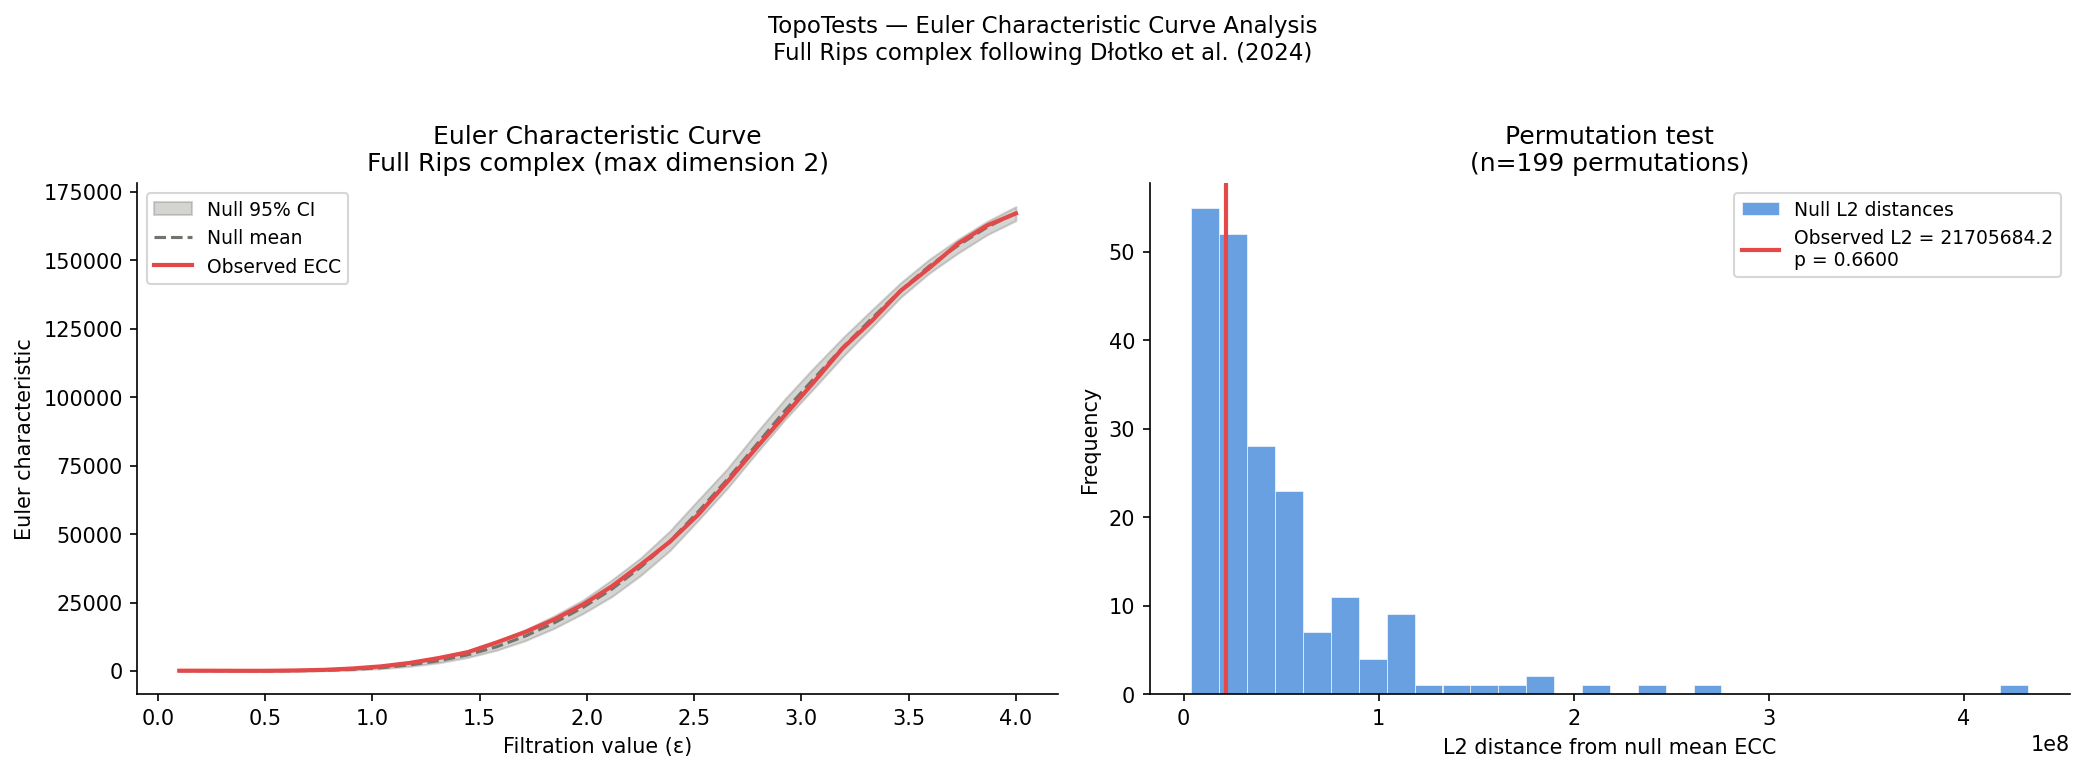

Saved CM_04.


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 8 — TOPOTESTS
# Full Euler Characteristic Curve via gudhi Rips complex (max dimension 2)
# Formal inferential complement to Ball Mapper
# Following Dlotko et al. (2024)
# ═══════════════════════════════════════════════════════════════════════════

import gudhi
import time

def ecc_full(X, filtration_vals):
    """
    Full ECC using gudhi Rips complex up to dimension 2.
    EC = sum over all simplices of (-1)^dim for filtration <= t.
    """
    rips     = gudhi.RipsComplex(points=X,
                                  max_edge_length=max(filtration_vals))
    st       = rips.create_simplex_tree(max_dimension=2)
    simplices = [(len(s)-1, f) for s, f in st.get_filtration()]
    ecc = []
    for t in filtration_vals:
        ec = sum((-1)**dim for dim, f in simplices if f <= t)
        ecc.append(ec)
    return np.array(ecc)

filtration_vals_full = np.linspace(0.1, 4.0, 30)
n_perm = 199

# Observed ECC
print("Computing full ECC for observed point cloud...")
start = time.time()
ecc_observed_full = ecc_full(X_scaled, filtration_vals_full)
print(f"Done in {time.time()-start:.1f}s")

# Null distribution
print(f"\nComputing null distribution ({n_perm} permutations)...")
print("Estimated time: ~4-5 minutes. Please wait...")
ecc_null_full = []
start = time.time()

for i in range(n_perm):
    if i % 40 == 0:
        elapsed = time.time() - start
        eta     = (elapsed / (i+1)) * (n_perm-i) if i > 0 else 0
        print(f"  {i}/{n_perm} — elapsed {elapsed:.0f}s — ETA {eta:.0f}s")
    X_perm       = X_scaled.copy()
    X_perm[:, 0] = np.random.permutation(X_perm[:, 0])
    ecc_null_full.append(ecc_full(X_perm, filtration_vals_full))

ecc_null_full = np.array(ecc_null_full)
print(f"Done in {time.time()-start:.0f}s")

# Test statistic
ecc_null_mean_f  = ecc_null_full.mean(axis=0)
ecc_null_upper_f = np.percentile(ecc_null_full, 97.5, axis=0)
ecc_null_lower_f = np.percentile(ecc_null_full, 2.5, axis=0)

L2_obs_full  = np.sum((ecc_observed_full - ecc_null_mean_f)**2)
L2_null_full = np.sum((ecc_null_full - ecc_null_mean_f)**2, axis=1)
p_value_full = (np.sum(L2_null_full >= L2_obs_full) + 1) / (n_perm + 1)

print(f"\nTopoTests Results (full Rips complex, max dimension 2):")
print(f"  Filtration values:                 {len(filtration_vals_full)}")
print(f"  Permutations:                      {n_perm}")
print(f"  L2 observed vs null mean:          {L2_obs_full:.4f}")
print(f"  Permutation p-value:               {p_value_full:.4f}")
print(f"  Significant at 0.05:               {p_value_full < 0.05}")
print(f"  Significant at 0.01:               {p_value_full < 0.01}")

# Save results
topo_results = pd.DataFrame([{
    'L2_observed':       round(L2_obs_full, 4),
    'p_value':           round(p_value_full, 4),
    'n_permutations':    n_perm,
    'filtration_values': len(filtration_vals_full),
    'max_dimension':     2,
    'significant_005':   p_value_full < 0.05,
    'significant_001':   p_value_full < 0.01,
    'method':            'Full Rips complex ECC, max dimension 2, gudhi',
    'permutation_axis':  'Prescribing rate (axis 0)',
}])
topo_results.to_csv(f'{TAB_PATH}/topotests_results.csv', index=False)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].fill_between(filtration_vals_full,
                     ecc_null_lower_f, ecc_null_upper_f,
                     alpha=0.3, color=GREY, label='Null 95% CI')
axes[0].plot(filtration_vals_full, ecc_null_mean_f,
             color=GREY, linewidth=1.5, linestyle='--',
             label='Null mean')
axes[0].plot(filtration_vals_full, ecc_observed_full,
             color=RED, linewidth=2, label='Observed ECC')
axes[0].set_xlabel('Filtration value (ε)')
axes[0].set_ylabel('Euler characteristic')
axes[0].set_title('Euler Characteristic Curve\n'
                  'Full Rips complex (max dimension 2)')
axes[0].legend(fontsize=9)

axes[1].hist(L2_null_full, bins=30, color=BLUE, alpha=0.7,
             edgecolor='white', linewidth=0.4,
             label='Null L2 distances')
axes[1].axvline(L2_obs_full, color=RED, linewidth=2,
                label=f'Observed L2 = {L2_obs_full:.1f}\n'
                      f'p = {p_value_full:.4f}')
axes[1].set_xlabel('L2 distance from null mean ECC')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Permutation test\n(n={n_perm} permutations)')
axes[1].legend(fontsize=9)

plt.suptitle('TopoTests — Euler Characteristic Curve Analysis\n'
             'Full Rips complex following Dłotko et al. (2024)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIG_PATH}/CM_04_topotests.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved CM_04.")

In [11]:
# ── Update comparison summary with TopoTests result ───────────────────────
summary_data_final = [
    {
        'Method': 'OLS Regression',
        'Question addressed': 'Is prescribing linearly predicted by retail and IMD?',
        'Key statistic': 'R² = 0.065',
        'Result': 'Retail not significant (p=0.519); IMD weakly significant (p=0.009)',
        'What it cannot do': 'Cannot detect non-linear or heterogeneous structure',
        'Ball Mapper adds': 'Reveals N2 and N8 — opposite behaviours OLS averages into one slope'
    },
    {
        'Method': "Global Moran's I",
        'Question addressed': 'Are variables geographically clustered in physical space?',
        'Key statistic': 'I = 0.044–0.112 (all p<0.01)',
        'Result': 'Significant but weak geographic clustering across all four variables',
        'What it cannot do': 'Cannot identify variable-space clusters across multiple dimensions',
        'Ball Mapper adds': 'Identifies structural clusters regardless of geographic proximity'
    },
    {
        'Method': 'K-means (k=12)',
        'Question addressed': 'What partition does conventional variable-space clustering find?',
        'Key statistic': f'ARI vs Ball Mapper = {ari_km:.3f}',
        'Result': 'Low agreement; most BM nodes split across 2–7 k-means clusters',
        'What it cannot do': 'Hard convex boundaries cannot represent structural overlap',
        'Ball Mapper adds': 'Overlapping membership preserves N2–N8 structural adjacency'
    },
    {
        'Method': 'TopoTests (full ECC, dim=2)',
        'Question addressed': 'Does global topology of point cloud deviate from null?',
        'Key statistic': f'p = {p_value_full:.4f}',
        'Result': 'Non-significant — global ECC does not deviate from permutation null',
        'What it cannot do': 'Global test cannot detect local structural clusters at n=106',
        'Ball Mapper adds': 'Reveals local structure (N3 isolated) invisible to global ECC'
    },
]

summary_df_final = pd.DataFrame(summary_data_final)
summary_df_final.to_csv(f'{TAB_PATH}/comparison_methods_summary.csv',
                         index=False)

print("Updated comparison_methods_summary.csv with TopoTests result.")
print(f"\nFINAL COMPARISON METHODS SUMMARY:")
print("="*80)
for _, row in summary_df_final.iterrows():
    print(f"\n{row['Method']}")
    print(f"  Key stat:  {row['Key statistic']}")
    print(f"  Result:    {row['Result']}")
print("\n" + "="*80)
print(f"Overall finding: conventional methods collectively establish that")
print(f"prescribing variation is non-linear (OLS R²=0.065), geographically")
print(f"weak (Moran's I<0.12), and structurally distinct from k-means")
print(f"partitions (ARI={ari_km:.3f}). Ball Mapper reveals local topological")
print(f"structure that none of these methods can replicate.")

Updated comparison_methods_summary.csv with TopoTests result.

FINAL COMPARISON METHODS SUMMARY:

OLS Regression
  Key stat:  R² = 0.065
  Result:    Retail not significant (p=0.519); IMD weakly significant (p=0.009)

Global Moran's I
  Key stat:  I = 0.044–0.112 (all p<0.01)
  Result:    Significant but weak geographic clustering across all four variables

K-means (k=12)
  Key stat:  ARI vs Ball Mapper = 0.307
  Result:    Low agreement; most BM nodes split across 2–7 k-means clusters

TopoTests (full ECC, dim=2)
  Key stat:  p = 0.6600
  Result:    Non-significant — global ECC does not deviate from permutation null

Overall finding: conventional methods collectively establish that
prescribing variation is non-linear (OLS R²=0.065), geographically
weak (Moran's I<0.12), and structurally distinct from k-means
partitions (ARI=0.307). Ball Mapper reveals local topological
structure that none of these methods can replicate.


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 9 — FINAL SAVE AND COMMIT PREP
# ═══════════════════════════════════════════════════════════════════════════

# Save updated dataset with centroids and cluster assignments
df.to_csv(
    r'C:\Users\namra\gluten-free-spatial-inequality\data\processed\analytical_dataset_final.csv',
    index=False)
print("Updated analytical_dataset_final.csv with centroids and k-means labels.")

# Summary of all outputs
print("\nFigures saved in this notebook:")
figures = [
    'CM_01_OLS_diagnostics.png',
    'CM_02_morans_i.png',
    'CM_02b_morans_summary.png',
    'CM_03_kmeans_vs_ballmapper.png',
    'CM_03b_kmeans_bm_comparison.png',
    'CM_04_topotests.png',
]
for f in figures:
    print(f"  outputs/figures/{f}")

print("\nTables saved:")
tables = [
    'OLS_results.csv',
    'morans_i_results.csv',
    'kmeans_cluster_summary.csv',
    'topotests_results.csv',
    'comparison_methods_summary.csv',
]
for t in tables:
    print(f"  outputs/tables/{t}")

print("\nNotebook 04 complete. Ready to commit.")
print("\nRun in terminal:")
print("  git add .")
print('  git commit -m "Notebook 04 complete: OLS R2=0.065, '
      "Moran's I all p<0.01 weak, k-means ARI=0.307, "
      'TopoTests full Rips p=0.660"')
print("  git push origin main")

Updated analytical_dataset_final.csv with centroids and k-means labels.

Figures saved in this notebook:
  outputs/figures/CM_01_OLS_diagnostics.png
  outputs/figures/CM_02_morans_i.png
  outputs/figures/CM_02b_morans_summary.png
  outputs/figures/CM_03_kmeans_vs_ballmapper.png
  outputs/figures/CM_03b_kmeans_bm_comparison.png
  outputs/figures/CM_04_topotests.png

Tables saved:
  outputs/tables/OLS_results.csv
  outputs/tables/morans_i_results.csv
  outputs/tables/kmeans_cluster_summary.csv
  outputs/tables/topotests_results.csv
  outputs/tables/comparison_methods_summary.csv

Notebook 04 complete. Ready to commit.

Run in terminal:
  git add .
  git commit -m "Notebook 04 complete: OLS R2=0.065, Moran's I all p<0.01 weak, k-means ARI=0.307, TopoTests full Rips p=0.660"
  git push origin main
